<a href="https://colab.research.google.com/github/NewbieHocIT/HocMay/blob/main/Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 !pip install pyvi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.4 MB/s eta 0:00:00


In [ ]:
!pip install unidecode


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 13.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Libraries to create and train our model
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Embedding ,GRU, Input
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.optimizers import Adam ,SGD
from tensorflow.keras.preprocessing.sequence  import pad_sequences

from pyvi import ViTokenizer
from pyvi import ViUtils




In [ ]:
from google.colab import drive

# Kết nối Google Drive
drive.mount('/content/drive', force_remount=True)

file_path = '/content/drive/MyDrive/data/Sentiment_Analysis_VN2.csv'

# Đọc tệp CSV vào DataFrame
df = pd.read_csv(file_path)

Mounted at /content/drive


In [ ]:
df.head()

,comment,label,rate,Unnamed: 3
0,Áo bao đẹp ạ!!,Tích cực,5,NaN
1,Tuyệt vời !,Tích cực,5,NaN
2,2 dây áo không giống trong hình.,Tiêu cực,1,NaN
3,"Mùi thơm,bôi lên da mềm da.",Tích cực,5,NaN
4,"Vải đẹp, dày dặn.",Tích cực,5,NaN


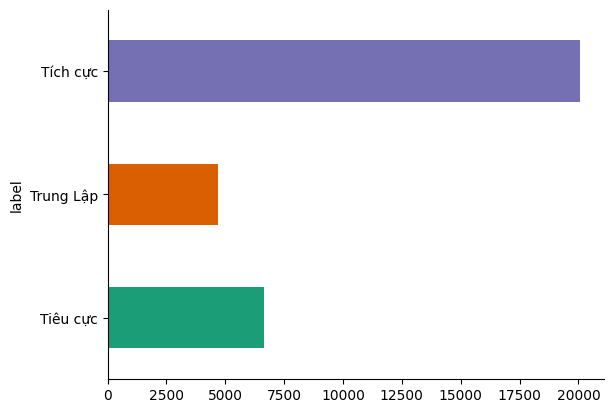

In [ ]:
# @title label

from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
new_data = pd.DataFrame ({'input' : df['comment'] , 'label' : df['label']})
new_data  = new_data.dropna()
new_data = new_data.reset_index(drop=True)
new_data.head()

,input,label
0,Áo bao đẹp ạ!!,Tích cực
1,Tuyệt vời !,Tích cực
2,2 dây áo không giống trong hình.,Tiêu cực
3,"Mùi thơm,bôi lên da mềm da.",Tích cực
4,"Vải đẹp, dày dặn.",Tích cực


In [ ]:
import pandas as pd
import random

# Hàm thực hiện data augmentation
def augment_data(df):
    augmented_data = []
    for index, row in df.iterrows():
        if row['label'] in ['Tích cực' ,'Tiêu cực', 'Trung Lập']:  # Chỉ thực hiện data augmentation cho các nhãn tiêu cực và trung tính
            # Thêm biến thể gốc vào dữ liệu mới
            augmented_data.append(row)

            # Tạo các biến thể mới và thêm vào dữ liệu mới
            # Ví dụ: thêm một số dấu câu ngẫu nhiên vào cuối câu
            for _ in range(1):  # Tạo 3 biến thể mới cho mỗi mẫu
                new_row = row.copy()
                new_row['input'] += ''.join(random.choices(['!', '.', '?'], k=random.randint(1, 3)))
                augmented_data.append(new_row)

    # Ghép các dữ liệu mới vào DataFrame
    augmented_df = pd.DataFrame(augmented_data)
    return augmented_df


data = pd.DataFrame(new_data)

# Tạo DataFrame mới từ 'sentiment_data'
sentiment_data = pd.DataFrame({'input': df['comment'], 'label': df['label']})
sentiment_data = sentiment_data.dropna()
sentiment_data = sentiment_data.reset_index(drop=True)

# Sử dụng hàm augment_data để tạo dữ liệu mới từ 'sentiment_data'
augmented_df = augment_data(sentiment_data)

# Ghép DataFrame gốc và DataFrame mới từ data augmentation
combined_df = pd.concat([new_data, augmented_df], ignore_index=True)

# Hiển thị 20 dòng đầu tiên của DataFrame kết hợp
print(combined_df.head(20))


                                                input      label
0                                      Áo bao đẹp ạ!!   Tích cực
1                                         Tuyệt vời !   Tích cực
2                    2 dây áo không giống trong hình.   Tiêu cực
3                         Mùi thơm,bôi lên da mềm da.   Tích cực
4                                   Vải đẹp, dày dặn.   Tích cực
5                     Hàng rất đẹp, rất chi là ưng ý.   Tích cực
6                   Chất lượng sản phẩm tốt, hạn dài.   Tích cực
7                      Ăn nói và thái độ phục vụ tốt.   Tích cực
8                        Đóng gói sản phẩm chắc chắn.   Tích cực
9                 tất sờn hết ca chưa dùng mà vay rồi   Tiêu cực
10                          cửa hàng phục vụ rất tốt.   Tích cực
11                                 Mặc thì cũng được.  Trung Lập
12                                 Chất vải khỏi chê.   Tích cực
13                     Thời gian giao hàng rất nhanh.   Tích cực
14                     Ch

In [ ]:

augmented_df

,input,label
0,Áo bao đẹp ạ!!,Tích cực
0,Áo bao đẹp ạ!!!,Tích cực
1,Tuyệt vời !,Tích cực
1,Tuyệt vời !!?,Tích cực
2,2 dây áo không giống trong hình.,Tiêu cực
...,...,...
31429,Hàng đẹp đúng giá tiền.?.!,Tích cực
31430,Chất vải khá ổn.,Tích cực
31430,Chất vải khá ổn..!,Tích cực
31431,"áo rất tốt nhé , vải mịn , len cao cổ này phối...",Tích cực


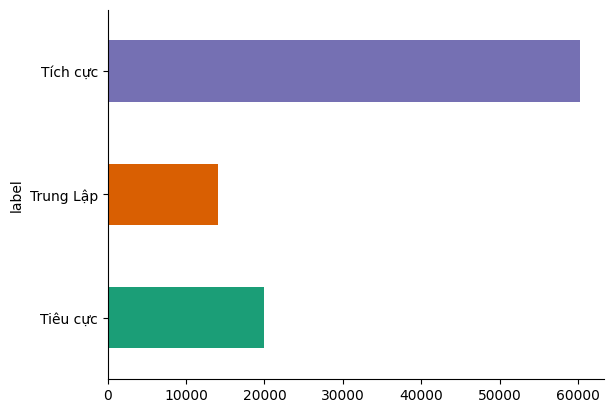

In [ ]:
# @title label

from matplotlib import pyplot as plt
import seaborn as sns
combined_df.groupby('label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
import re
import tensorflow as tf
from pyvi import ViTokenizer

def remove_special_icons(text):
    # Define a regular expression pattern to match emoji and special icons
    pattern = re.compile("["
                         u"\U0001F600-\U0001F64F"  # emoticons
                         u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                         u"\U0001F680-\U0001F6FF"  # transport & map symbols
                         u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                         u"\U00002500-\U00002BEF"  # chinese char
                         u"\U00002702-\U000027B0"
                         u"\U00002702-\U000027B0"
                         u"\U000024C2-\U0001F251"
                         u"\U0001f926-\U0001f937"
                         u"\U00010000-\U0010ffff"
                         u"\u2640-\u2642"
                         u"\u2600-\u2B55"
                         u"\u200d"
                         u"\u23cf"
                         u"\u23e9"
                         u"\u231a"
                         u"\ufe0f"  # dingbats
                         u"\u3030"
                         "]+", flags=re.UNICODE)
    # Remove special icons from the text
    text = pattern.sub(r'', text)
    return text

input_data = combined_df['input'].values
input_label = combined_df['label'].values
label_dict = {'Tiêu cực': 0, 'Trung Lập': 1, 'Tích cực': 2}
input_pre = []
label_with_accent = []

for idx, dt in enumerate(input_data):
    input_text_pre = list(tf.keras.preprocessing.text.text_to_word_sequence(dt))
    input_text_pre = " ".join(input_text_pre)
    input_text_pre_no_accent = str(ViUtils.remove_accents(input_text_pre).decode("utf-8"))
    input_text_pre_accent = ViTokenizer.tokenize(input_text_pre)
    input_text_pre_no_accent = ViTokenizer.tokenize(input_text_pre_no_accent)

    # Remove special icons
    input_text_pre_accent = remove_special_icons(input_text_pre_accent)
    input_text_pre_no_accent = remove_special_icons(input_text_pre_no_accent)

    input_pre.append(input_text_pre_accent)
    input_pre.append(input_text_pre_no_accent)
    label_with_accent.append(label_dict[input_label[idx]])
    label_with_accent.append(label_dict[input_label[idx]])


In [ ]:
 input_pre


['áo bao đẹp ạ',
 'ao bao dep a',
 'tuyệt_vời',
 'tuyet voi',
 '2 dây áo không giống trong hình',
 '2 day ao khong giong trong hinh',
 'mùi thơm bôi lên da mềm da',
 'mui thom boi len da mem da',
 'vải đẹp dày_dặn',
 'vai dep day dan',
 'hàng rất đẹp rất chi là ưng_ý',
 'hang rat dep rat chi la_ung y',
 'chất_lượng sản_phẩm tốt hạn dài',
 'chat luong san pham tot han dai',
 'ăn_nói và thái_độ phục_vụ tốt',
 'an noi va thai do phuc vu tot',
 'đóng_gói sản_phẩm chắc_chắn',
 'dong goi san pham chac chan',
 'tất sờn hết ca chưa dùng mà vay rồi',
 'tat son het ca chua dung ma vay roi',
 'cửa_hàng_phục_vụ rất tốt',
 'cua hang phuc vu rat tot',
 'mặc thì cũng được',
 'mac thi cung duoc',
 'chất vải khỏi chê',
 'chat vai khoi che',
 'thời_gian giao hàng rất nhanh',
 'thoi gian giao hang rat nhanh',
 'chất_lượng sản_phẩm tuyệt_vời',
 'chat luong san pham tuyet voi',
 'vải hơi thô cứng thời_gian giao hàng nhanh',
 'vai hoi tho cung thoi gian giao hang_nhanh',
 'chất_lượng sản_phẩm chưa thật_sự đ

In [ ]:
len(input_pre)

188592

<Axes: >

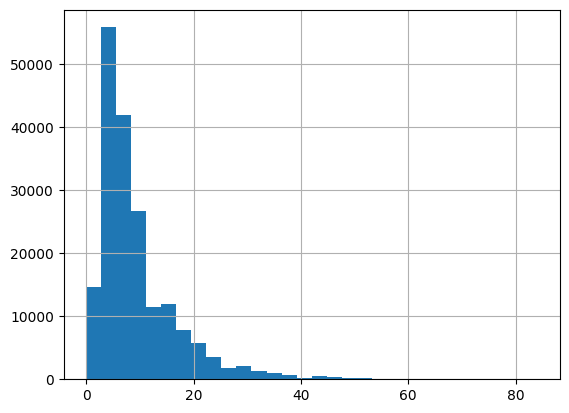

In [ ]:
# get length of all the messages in the train set
seq_len = [len(i.split()) for i in input_pre]

pd.Series(seq_len).hist(bins=30)


In [ ]:
import pickle
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Giả sử label_with_accent là danh sách các nhãn
# input_pre là danh sách các câu hoặc văn bản
# Đảm bảo rằng chúng được định nghĩa trước khi chạy đoạn mã này

# Chuyển đổi nhãn sang dạng one-hot encoding
label_tf = to_categorical(label_with_accent, num_classes=3)

# Tạo tokenizer và huấn luyện trên dữ liệu văn bản
tokenizer_data = Tokenizer(oov_token='<OOV>', filters=' ', split=' ')
tokenizer_data.fit_on_texts(input_pre)

# Chuyển đổi văn bản thành các chuỗi số
tokenized_data_text = tokenizer_data.texts_to_sequences(input_pre)

# Đệm các chuỗi để đảm bảo tất cả có độ dài bằng nhau
vec_data = pad_sequences(tokenized_data_text, padding='post', maxlen=10)

# Lưu tokenizer vào file
with open("tokenizer_data.pkl", "wb") as tokenizer_file:
    pickle.dump(tokenizer_data, tokenizer_file)

# In ra kích thước dữ liệu
print("input data shape:", vec_data.shape)

# Kích thước từ điển
data_vocab_size = len(tokenizer_data.word_index) + 1
print("data vocab size:", data_vocab_size)

# Chia dữ liệu thành tập huấn luyện, tập kiểm tra, và tập kiểm thử
X_train, X_val, y_train, y_val = train_test_split(vec_data, label_tf, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

# In ra số lượng mẫu trong mỗi tập
print("training sample:", len(X_train))
print("validation sample:", len(X_val))
print("test sample:", len(X_test))


input data shape: (188592, 10)
data vocab size: 9831
training sample: 135785
validation sample: 37719
test sample: 15088


In [ ]:
# In ra từ điển của tokenizer
print("Từ điển của tokenizer:")
print(tokenizer_data.word_index)

print("Các câu đầu tiên đã được mã hóa:")
for i, sequence in enumerate(tokenized_data_text[:5]):
    print(f"Câu {i+1}: {sequence}")

# In ra chỉ vài câu đầu tiên được mã hóa dưới dạng one-hot
print("Các câu đầu tiên dưới dạng one-hot encoding:")
print(vec_data[:5])


Từ điển của tokenizer:
{'<OOV>': 1, 'hang': 2, 'rat': 3, 'rất': 4, 'giao': 5, 'san': 6, 'pham': 7, 'sản_phẩm': 8, 'dep': 9, 'chat': 10, 'đẹp': 11, 'cua': 12, 'hàng': 13, 'nhanh': 14, 'luong': 15, 'chất_lượng': 16, 'voi': 17, 'cửa_hàng': 18, 'tot': 19, 'tốt': 20, 'khong': 21, 'không': 22, 'ao': 23, 'áo': 24, 'tuyet': 25, 'va': 26, 'và': 27, 'mua': 28, 'goi': 29, 'tuyệt_vời': 30, 'dong': 31, 'dang': 32, 'tien': 33, 'đóng_gói': 34, 'chan': 35, 'chac': 36, 'tiền': 37, 'vai': 38, 'chắc_chắn': 39, 'nhung': 40, 'thoi': 41, 'gian': 42, 'cho': 43, 'nhưng': 44, 'vải': 45, 'được': 46, 'hoi': 47, 'mau': 48, 'đáng': 49, 'thời_gian': 50, 'phuc': 51, 'vu': 52, 'co': 53, 'minh': 54, 'duoc': 55, 'hinh': 56, 'cửa_hàng_phục_vụ': 57, 'lam': 58, 'mình': 59, 'hơi': 60, 'mac': 61, 'qua': 62, 'hình': 63, 'chất': 64, '1': 65, 'gia': 66, 'mặc': 67, 'màu': 68, 'lắm': 69, 'nhu': 70, 'so': 71, 'với': 72, 'có': 73, 'thi': 74, 'quá': 75, 'y': 76, 'thì': 77, 'cung': 78, 'ma': 79, 'mà': 80, 'may': 81, 'mong': 82, 'la'

#Tạo model



#LSTM

In [ ]:
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dropout, LayerNormalization, Dense, BatchNormalization
import tensorflow as tf

def generate_model():
    dropout_threshold = 0.3
    input_dim = data_vocab_size
    output_dim = 512
    input_length = 10
    initializer = tf.keras.initializers.GlorotNormal()

    # Define input layer
    input_layer = Input(shape=(input_length,))

    # Create feature embeddings
    embedding_layer = Embedding(input_dim=input_dim, output_dim=output_dim, input_length=input_length, embeddings_initializer="GlorotUniform")(input_layer)

    # Bidirectional LSTM layer
    lstm = Bidirectional(LSTM(units=64, dropout=dropout_threshold, return_sequences=True, kernel_initializer=initializer))(embedding_layer)
    lstm = LayerNormalization()(lstm)

    # Classifier
    classifier = LSTM(units=64, dropout=dropout_threshold, return_sequences=False, kernel_initializer=initializer)(lstm)
    classifier = Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(classifier)
    classifier = Dropout(0.3)(classifier)
    classifier = Dense(3, activation='softmax')(classifier)

    # Create model
    model = tf.keras.Model(inputs=input_layer, outputs=classifier)

    return model

# Create model
model = generate_model()

# Compile model
adam = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 10)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 10, 512)             │       5,033,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 10, 128)             │         295,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization                  │ (None, 10, 128)             │             256 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,382,915 (20.53 MB)

 Trainable params: 5,382,915 (20.53 MB)

 Non-trainable params: 0 (0.00 B)

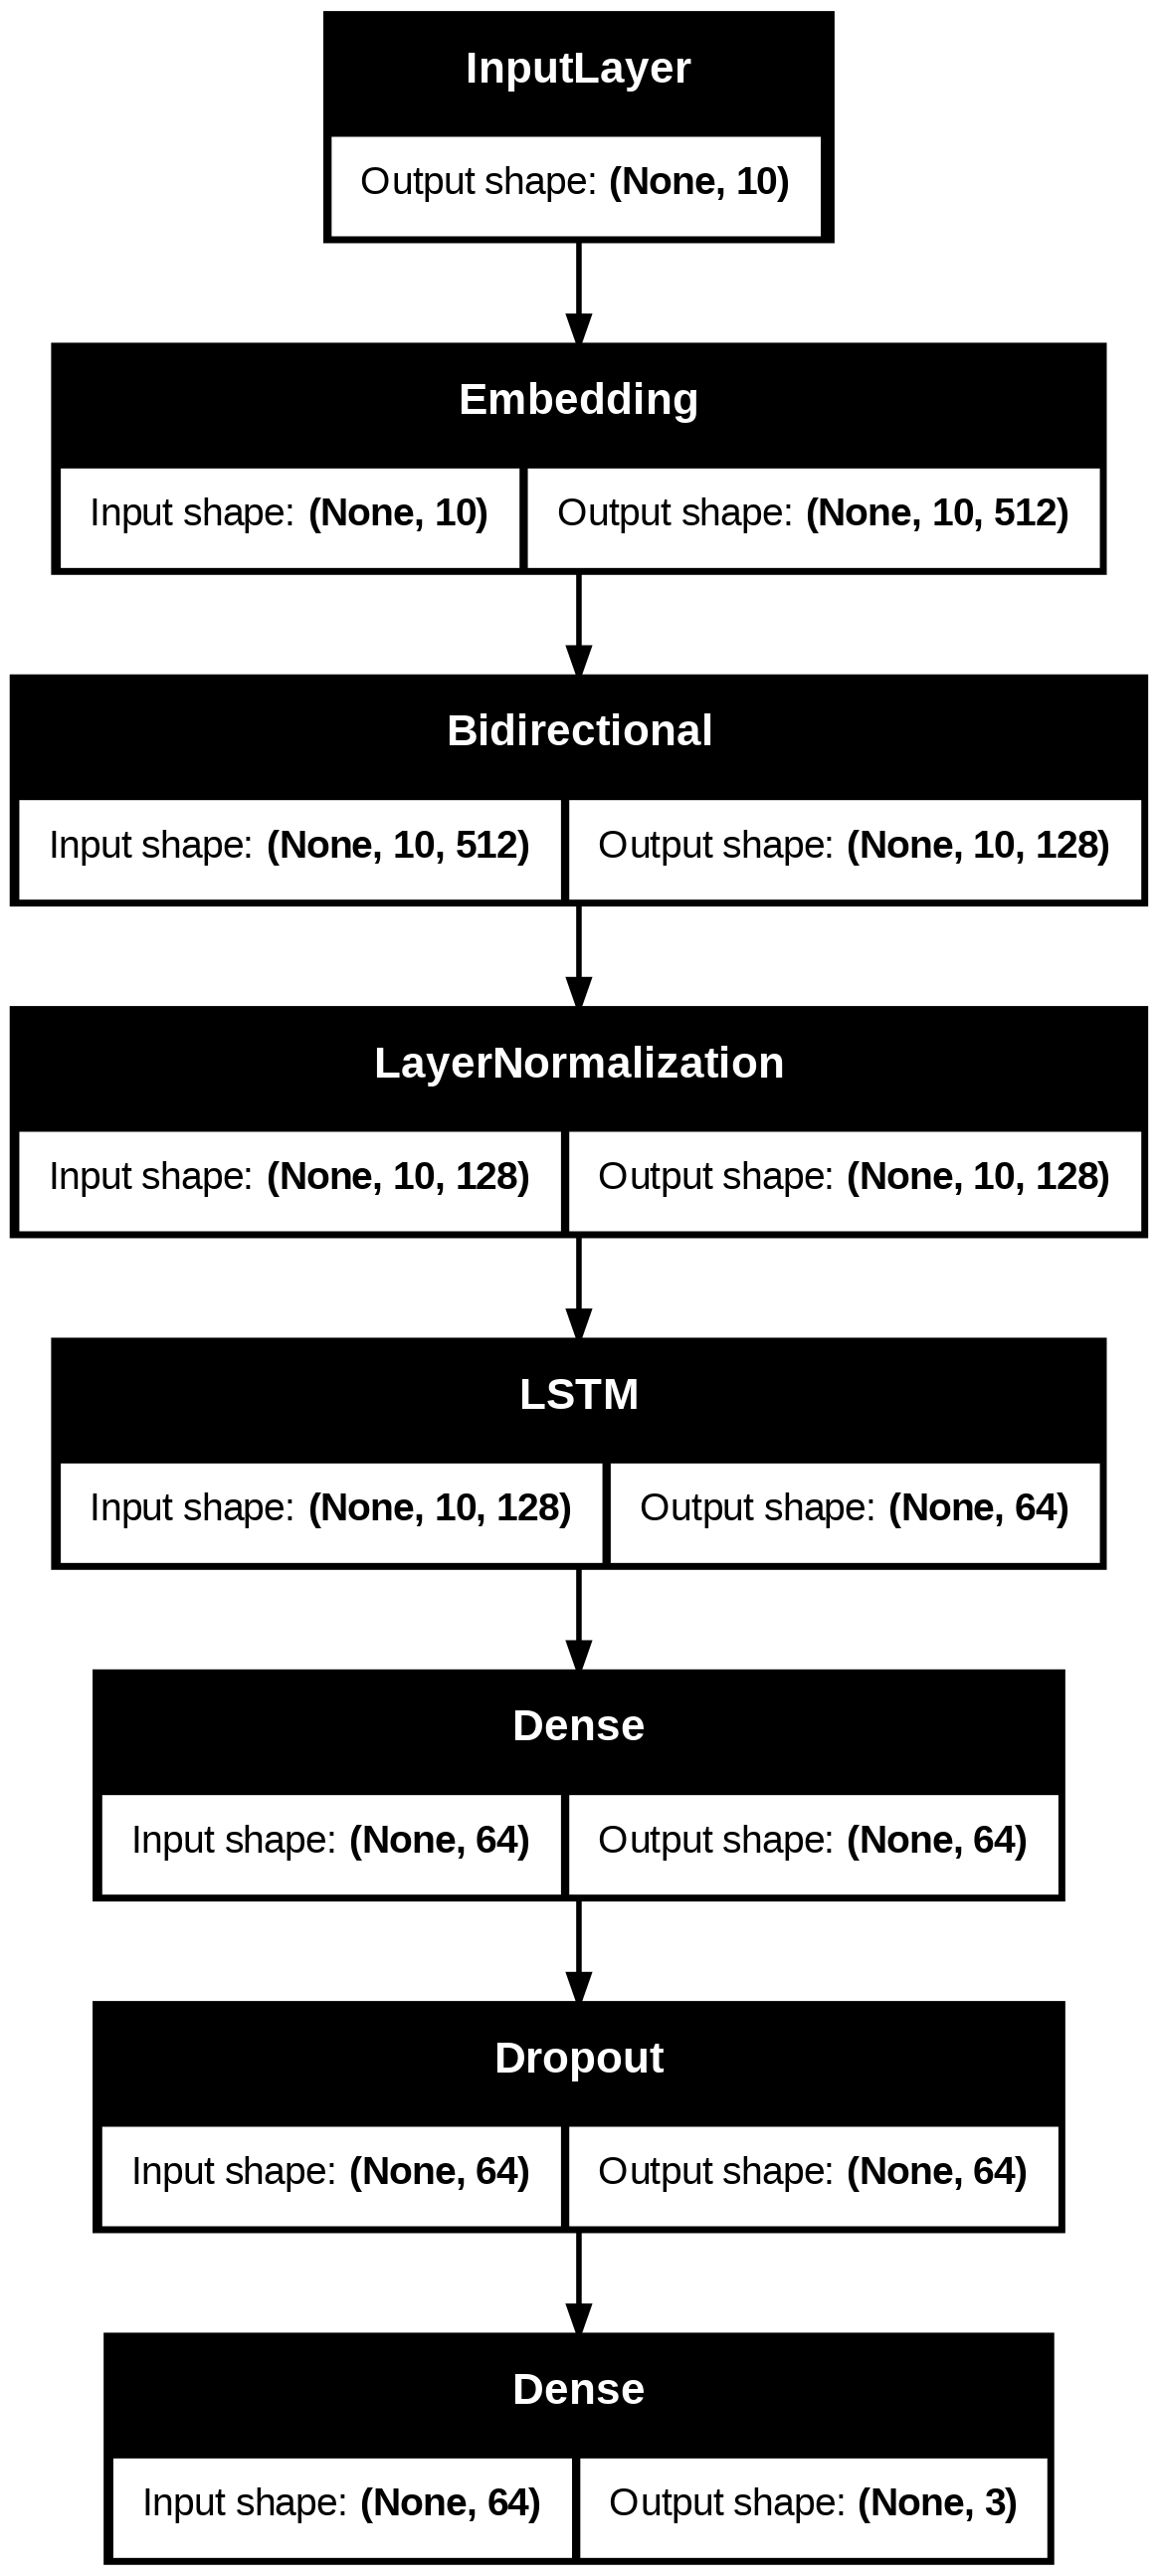

In [ ]:
dot_img_file = 'model_visualize.png'
tf.keras.utils.plot_model(model, to_file=dot_img_file, show_shapes=True)



In [ ]:
# Hàm callback để dừng huấn luyện khi đạt được độ chính xác mong muốn
class AccuracyCallback(Callback):
    def __init__(self, target_accuracy):
        super(AccuracyCallback, self).__init__()
        self.target_accuracy = target_accuracy
        self.start_time = None

    def on_epoch_begin(self, epoch, logs=None):
        if self.start_time is None:
            self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        current_accuracy = logs.get('val_accuracy') or logs.get('val_acc')
        if current_accuracy >= self.target_accuracy:
            end_time = time.time()
            total_time = end_time - self.start_time
            print(f"Target accuracy reached! Total training time: {total_time:.2f} seconds")

# Khởi tạo callback với độ chính xác mục tiêu là 0.8 (80%)
accuracy_callback = AccuracyCallback(target_accuracy=0.8)

In [ ]:
from keras.callbacks import ModelCheckpoint
import time
checkpoint = ModelCheckpoint('/content/model_adam-{epoch:03d}.h5',
                                 monitor='val_loss',
                                 verbose=0,
                                 save_best_only = True,
                                 mode='auto')

ValueError: The filepath provided must end in `.keras` (Keras model format). Received: filepath=/content/model_adam-{epoch:03d}.h5

Epoch 1/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7442 - loss: 0.8515 - val_accuracy: 0.8161 - val_loss: 0.4722
Epoch 2/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8331 - loss: 0.4423 - val_accuracy: 0.8442 - val_loss: 0.4178
Epoch 3/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8619 - loss: 0.3828 - val_accuracy: 0.8568 - val_loss: 0.3903
Epoch 4/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8798 - loss: 0.3371 - val_accuracy: 0.8685 - val_loss: 0.3678
Epoch 5/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8920 - loss: 0.3078 - val_accuracy: 0.8795 - val_loss: 0.3431
Epoch 6/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9002 - loss: 0.2851 - val_accuracy: 0.8865 - val_loss: 0.3251
Epoch 7/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9088 - loss: 0.2653 - val_accuracy: 0.8914 - val_loss: 0.3173
Epoch 8/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9150 - loss: 0.2491 - va

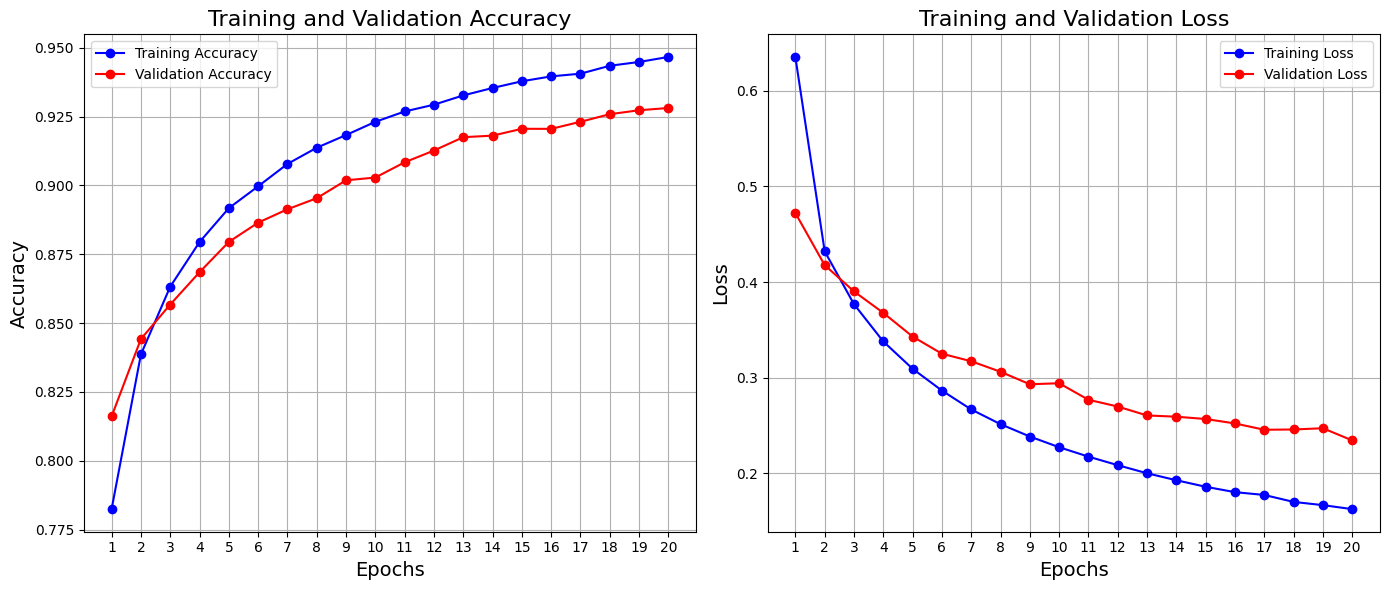

In [ ]:
import matplotlib.pyplot as plt

# Tiến hành huấn luyện với ModelCheckpoint để thu thập lịch sử
history = model.fit(x=X_train, y=y_train, epochs=20, validation_data=(X_val, y_val), batch_size=224)

# Trích xuất thông tin lịch sử huấn luyện
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Trích xuất số lượng epoch
epochs = range(1, len(train_acc) + 1)

# Tạo figure với kích thước lớn hơn
plt.figure(figsize=(14, 6))

# Vẽ biểu đồ độ chính xác trên tập huấn luyện và tập validation
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(epochs)
plt.legend()
plt.grid(True)

# Vẽ biểu đồ mất mát trên tập huấn luyện và tập validation
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.xticks(epochs)
plt.legend()
plt.grid(True)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9252 - loss: 0.2329
Test Loss: 0.2257261723279953
Test Accuracy: 0.9302094578742981


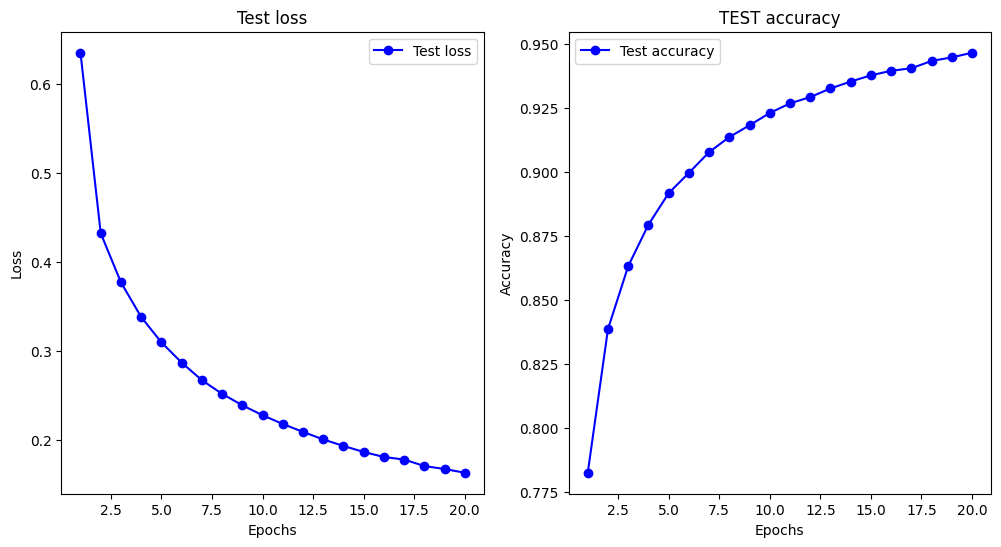

In [ ]:
# Đánh giá model trên tập test
test_loss, test_accuracy = model.evaluate(X_test, y_test, batch_size=224)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

# Vẽ đồ thị lịch sử huấn luyện
import matplotlib.pyplot as plt

# Lịch sử huấn luyện
history_dict = history.history

# Lấy giá trị loss và accuracy
loss_values = history_dict['loss']
accuracy_values = history_dict['accuracy']

# Số epoch
epochs = range(1, len(loss_values) + 1)

# Vẽ đồ thị loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, 'bo-', label='Test loss')
plt.title('Test loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Vẽ đồ thị accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy_values, 'bo-', label='Test accuracy')
plt.title('TEST accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
    # model là tên của model bạn muốn lưu
# file_name là tên file mà bạn muốn lưu model vào1
model.save('/content/drive/My Drive/Sentiment_Bi_LSTM.h5')  # Đường dẫn đến Google Drive


In [ ]:
my_model = load_model('/content/drive/My Drive/Sentiment_Bi_LSTM.h5')
from sklearn.metrics import classification_report
import numpy as np



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

conf_matrix = confusion_matrix(y_test_labels, predictions_labels)

# Vẽ ma trận phân loại sử dụng seaborn
plt.figure(figsize=(7, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', xticklabels=label, yticklabels=label)
plt.xlabel('Dự đoán', fontsize=14)
plt.ylabel('Nhãn thực', fontsize=14)
plt.title('Ma trận phân loại', fontsize=16)
plt.show()

In [ ]:
import pickle
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from pyvi import ViTokenizer

# Đường dẫn tới tệp trong Google Drive
file_path = '/content/drive/MyDrive/Colab Notebooks/tokenizer_data.pkl'

# Tải tokenizer từ tệp
with open(file_path, "rb") as input_file:
    my_tokenizer = pickle.load(input_file)

# Tải mô hình
my_model = load_model('/content/drive/My Drive/Sentiment_Bi_LSTM.h5')


# Thực hiện dự đoán
def preprocess_raw_input(raw_input, tokenizer):
    input_text_pre = list(tf.keras.preprocessing.text.text_to_word_sequence(raw_input))
    input_text_pre = " ".join(input_text_pre)
    input_text_pre_accent = ViTokenizer.tokenize(input_text_pre)
    print("Text preprocessed:", input_text_pre_accent)
    tokenized_data_text = tokenizer.texts_to_sequences([input_text_pre_accent])
    vec_data = pad_sequences(tokenized_data_text, padding='post', maxlen=10)
    return vec_data

def inference_model(input_feature, model):
    output = model(input_feature).numpy()
    result = np.argmax(output)
    conf = float(np.max(output))
    label_dict = {0: 'Tiêu cực', 1: 'Trung Lập', 2: 'Tích cực'}
    return label_dict[result], conf

def prediction(raw_input, tokenizer, model):
    input_model = preprocess_raw_input(raw_input, tokenizer)
    result, conf = inference_model(input_model, model)
    return result, conf

# Dự đoán một câu
print(prediction("chết tie", my_tokenizer, my_model))


Text preprocessed: bạn thật dễ_thương
('Tích cực', 0.9975791573524475)


In [ ]:

while(True):
    text = input ()
    if text == "end":
        break
    else:
        print(prediction(text, my_tokenizer, my_model)[0]+" \n " )
